In [ ]:
!unzip -q /content/cnn-lstm-project-images.zip -d /content/

In [ ]:
import os

# List the contents of the unzipped directory
print(os.listdir('/content/cnn-lstm-project-images/'))

['sequence1', 'sequence2', 'README.md', 'sequence4', '.git', 'sequence3']


In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import cv2 # For image processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Define image parameters
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
SEQUENCE_LENGTH = 8 # Number of frames per sequence for LSTM

print("Libraries imported and parameters defined.")

Libraries imported and parameters defined.


In [ ]:
def load_and_preprocess_data(base_path, img_height, img_width, sequence_length):
    all_sequences = []
    all_labels = []
    label_names = []

    # Iterate through each sequence directory (e.g., sequence1, sequence2)
    for sequence_dir_name in sorted(os.listdir(base_path)):
        sequence_path = os.path.join(base_path, sequence_dir_name)
        # Skip non-directories, .git, and __MACOSX directories
        if not os.path.isdir(sequence_path) or sequence_dir_name in ['.git', '__MACOSX']:
            continue

        # Iterate through each action directory (e.g., 1.Mid defalt, 2.Brush)
        for action_dir_name in sorted(os.listdir(sequence_path)):
            action_path = os.path.join(sequence_path, action_dir_name)
            if not os.path.isdir(action_path):
                # Skip files within sequence directories (e.g., .DS_Store or images directly inside sequence folders)
                continue

            # Extract label, handling both 'Number.ActionName' and 'ActionName' formats
            parts = action_dir_name.split('.', 1)
            if len(parts) >= 2:
                label = parts[1].strip() # Use part after the first dot
            else:
                label = action_dir_name.strip() # Use the full directory name as label

            # Ensure label is not empty after stripping
            if not label:
                print(f"Warning: Skipping directory with empty label after processing: {action_dir_name} in {sequence_path}")
                continue

            if label not in label_names:
                label_names.append(label)

            images = []
            # Load all image paths in the current action directory
            for img_name in sorted(os.listdir(action_path)):
                # Ensure we handle both .jpg and .png files
                if img_name.endswith('.jpg') or img_name.endswith('.png'):
                    img_path = os.path.join(action_path, img_name)
                    images.append(img_path)

            # Create sequences of images and assign the label
            for i in range(0, len(images) - sequence_length + 1):
                sequence = images[i : i + sequence_length]
                all_sequences.append(sequence)
                all_labels.append(label)

    # Encode labels to integers
    label_encoder = LabelEncoder()
    # Check if there are any labels to encode before calling fit_transform
    if not all_labels:
        print("Error: No labels found after processing directories. Check data structure.")
        return np.array([]), np.array([]), 0, np.array([]) # Return empty arrays if no labels

    encoded_labels = label_encoder.fit_transform(all_labels)
    num_classes = len(label_encoder.classes_)

    # Load and preprocess images for each sequence
    X_processed = []
    y_processed = []

    for i, seq_paths in enumerate(all_sequences):
        sequence_frames = []
        for img_path in seq_paths:
            img = cv2.imread(img_path) # Load image
            if img is None:
                print(f"Warning: Could not load image {img_path}. Skipping sequence associated with {all_labels[i]}...")
                sequence_frames = [] # Clear frames to mark as incomplete
                break
            img = cv2.resize(img, (img_width, img_height)) # Resize image
            img = img / 255.0 # Normalize pixel values
            sequence_frames.append(img)

        if len(sequence_frames) == sequence_length: # Only add complete sequences
            X_processed.append(np.array(sequence_frames))
            y_processed.append(encoded_labels[i]) # Append the corresponding encoded label
        else:
            print(f"Warning: Skipping incomplete sequence (length {len(sequence_frames)} != {sequence_length}) for label {all_labels[i]}.")

    X = np.array(X_processed)
    y = np.array(y_processed)

    print(f"Loaded {len(X)} sequences.")
    print(f"Number of classes: {num_classes}")
    print(f"Class labels: {label_encoder.classes_}")

    return X, y, num_classes, label_encoder.classes_

# Base path for the minimap frames
BASE_DATA_PATH = '/content/cnn-lstm-project-images/'

# Load and preprocess data
X, y, num_classes, class_labels = load_and_preprocess_data(
    BASE_DATA_PATH, IMG_HEIGHT, IMG_WIDTH, SEQUENCE_LENGTH
)

# Split data into training and testing sets
# Ensure X and y are not empty before splitting
if len(X) > 0 and len(y) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")
else:
    print("No data loaded for training. Check data path and structure.")
    # Define X_train, X_test, y_train, y_test as empty arrays to prevent NameError in subsequent cells
    X_train, X_test, y_train, y_test = np.array([]), np.array([]), np.array([]), np.array([])

Loaded 133 sequences.
Number of classes: 8
Class labels: ['AreaHold' 'Brush' 'HoldBSite' 'Mid defalt' 'RegroupGoA' 'SlowGoA'
 'TakeAMain' 'TakeGarage']
X_train shape: (106, 8, 64, 64, 3)
y_train shape: (106,)
X_test shape: (27, 8, 64, 64, 3)
y_test shape: (27,)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# X_train に含まれるすべてのシーケンスを順に表示

print(f"{len(X_train)} 個のトレーニングシーケンスを視覚化します。")

for i in range(len(X_train)): # すべてのシーケンスをループ
    sequence = X_train[i]
    label_encoded = y_train[i]
    label_name = class_labels[label_encoded]

    # figsize を変更して画像を拡大
    fig, axes = plt.subplots(1, SEQUENCE_LENGTH, figsize=(20, 3)) # 以前の (15, 2) から拡大
    fig.suptitle(f"シーケンス {i+1} / {len(X_train)}: ラベル '{label_name}'", fontsize=16)

    for frame_idx in range(SEQUENCE_LENGTH):
        ax = axes[frame_idx]
        ax.imshow(sequence[frame_idx])
        ax.set_title(f"フレーム {frame_idx + 1}", fontsize=8)
        ax.axis('off') # 軸を非表示にする

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()


In [ ]:
def build_cnn_lstm_model(img_height, img_width, sequence_length, num_classes):
    # Define the CNN part (Feature Extractor for each frame)
    cnn = keras.models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten() # Flatten the output to feed into LSTM
    ])

    # Define the CNN-LSTM model
    model = keras.models.Sequential([
        layers.TimeDistributed(cnn, input_shape=(sequence_length, img_height, img_width, 3)),
        layers.LSTM(128, return_sequences=False), # Only return the last output for classification
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax') # Output layer for classification
    ])

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Build the model
model = build_cnn_lstm_model(IMG_HEIGHT, IMG_WIDTH, SEQUENCE_LENGTH, num_classes)

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, 8, 4608)        │        93,248 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │     2,425,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,527,368 (9.64 MB)

 Trainable params: 2,527,368 (9.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
# You might want to adjust the number of epochs and batch size based on your dataset and computational resources
history = model.fit(
    X_train,
    y_train,
    epochs=15, # You can increase this for better training
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test)
)

print("Model training complete.")

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9528 - loss: 0.1550 - val_accuracy: 0.9259 - val_loss: 0.3115
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9717 - loss: 0.1446 - val_accuracy: 0.9259 - val_loss: 0.2441
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9717 - loss: 0.1450 - val_accuracy: 0.9259 - val_loss: 0.2669
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9717 - loss: 0.0964 - val_accuracy: 0.9259 - val_loss: 0.2892
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9811 - loss: 0.1035 - val_accuracy: 0.9259 - val_loss: 0.3060
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9717 - loss: 0.0860 - val_accuracy: 0.9259 - val_loss: 0.3197
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9623 - loss: 0.1186 - val_accuracy: 0.9259 - val_loss: 0.3137
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9717 - loss: 0.0876 - val_accuracy: 0.9259 - val_loss: 0.345

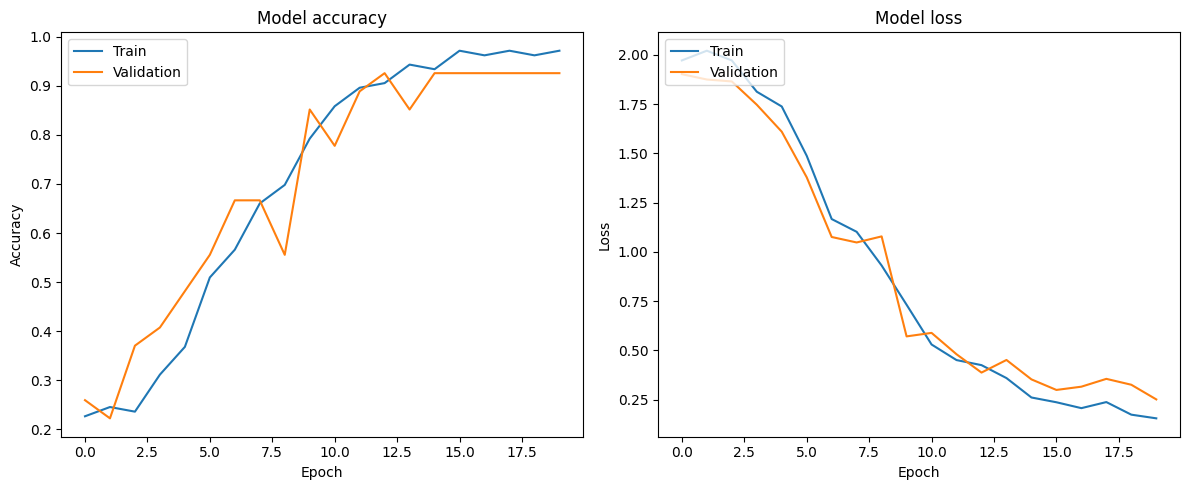

Training history plotted.


In [ ]:
import matplotlib.pyplot as plt

# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

print("Training history plotted.")

### テストデータでのモデルの評価

次に、訓練済みのモデルを使用してテストデータ `X_test` に対する予測を行い、その結果を元のラベル名に変換して表示します。

In [ ]:
print('テストデータでの予測を開始します...')

# テストデータで予測を行う
y_pred_probs = model.predict(X_test)

# 確率から予測クラスを取得（最も高い確率のインデックス）
y_pred = np.argmax(y_pred_probs, axis=1)

# 予測結果と実際のラベルを元のクラス名に変換
actual_labels = [class_labels[label] for label in y_test]
predicted_labels = [class_labels[label] for label in y_pred]

# 結果をDataFrameにまとめて表示
import pandas as pd
results_df = pd.DataFrame({
    'Actual Label': actual_labels,
    'Predicted Label': predicted_labels
})

print('予測結果:')
display(results_df)


テストデータでの予測を開始します...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
予測結果:


,Actual Label,Predicted Label
0,RegroupGoA,RegroupGoA
1,Brush,Brush
2,HoldBSite,HoldBSite
3,TakeAMain,TakeAMain
4,SlowGoA,SlowGoA
5,RegroupGoA,RegroupGoA
6,SlowGoA,SlowGoA
7,SlowGoA,SlowGoA
8,RegroupGoA,RegroupGoA
9,RegroupGoA,RegroupGoA


### モデルのパフォーマンス指標

モデルの全体的なパフォーマンスを評価するために、混同行列と分類レポートを表示します。

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12505 (\N{KATAKANA LETTER BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

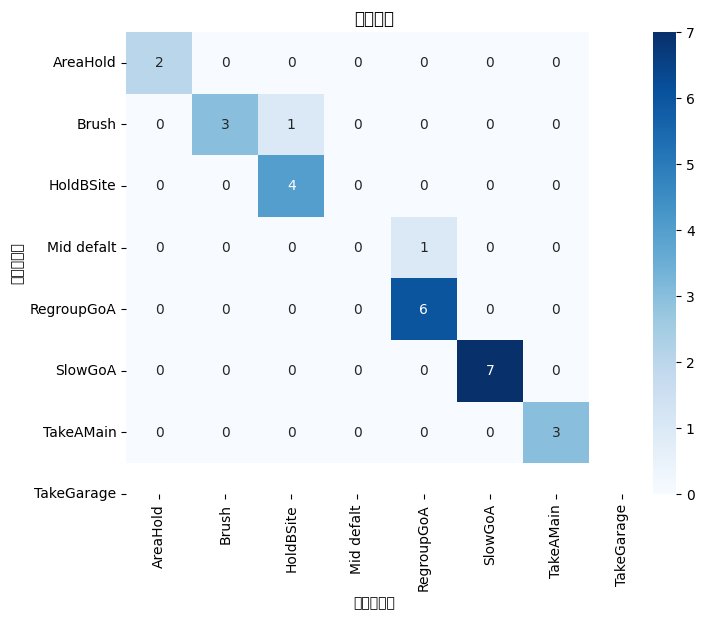


分類レポート:
              precision    recall  f1-score   support

    AreaHold       1.00      1.00      1.00         2
       Brush       1.00      0.75      0.86         4
   HoldBSite       0.80      1.00      0.89         4
  Mid defalt       0.00      0.00      0.00         1
  RegroupGoA       0.86      1.00      0.92         6
     SlowGoA       1.00      1.00      1.00         7
   TakeAMain       1.00      1.00      1.00         3
  TakeGarage       0.00      0.00      0.00         0

    accuracy                           0.93        27
   macro avg       0.71      0.72      0.71        27
weighted avg       0.90      0.93      0.91        27



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.arange

# 混同行列を計算
cm = confusion_matrix(y_test, y_pred)

# 混同行列をヒートマップで表示
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('予測ラベル')
plt.ylabel('真のラベル')
plt.title('混同行列')
plt.show()

# 分類レポートを表示
print('\n分類レポート:')
# Fix: Explicitly pass all possible labels to classification_report
print(classification_report(y_test, y_pred, labels=np.arange(num_classes), target_names=class_labels))
